# **SEGUNDA FASE DEL PROYECTO: ANÁLISIS DE ASOCIACIÓN Y AGRUPACIÓN**

Para mantener la claridad, la legibilidad y la modularidad del proyecto, el análisis se dividió en dos cuadernos de Jupyter, donde este segundo notebook se enfoca en la aplicación de algoritmos de minería de datos para identificar patrones de asociación y estructuras de agrupación sobre el dataset ya procesado.

El conjunto de datos utilizado en esta etapa corresponde al resultado final del proceso de limpieza y preprocesamiento realizado en el “Notebook 1”, y ha sido exportado y alojado en Hugging Face desde la siguiente fuente: [Dataset Fuente](https://huggingface.co/datasets/pauguzman/tmdb_mineria_datos_processed?utm_source=chatgpt.com)


### Carga del Dataset



#### - Instalar librerías necesarias:

In [ ]:
!pip install datasets

In [ ]:
!pip install datasets

#### - Para que no aparezcan mensajes de DeprecationWarning:

In [ ]:
import warnings

# Suppress DeprecationWarning specifically from jupyter_client.session
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client.session')
print("DeprecationWarning from jupyter_client.session suppressed.")

DeprecationWarning from jupyter_client.session suppressed.


#### - Cargar el dataset y conversión a DataFrame:

In [ ]:
from datasets import load_dataset
import pandas as pd

# Cargar el dataset desde Hugging Face
dataset = load_dataset("pauguzman/tmdb_mineria_datos_processed")

# Ver la estructura del dataset
print(dataset)

df = pd.DataFrame(dataset['train'])
df.head()

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'vote_average', 'vote_count', 'release_date', 'runtime', 'adult', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'release_year', 'duration_bin', 'highly_rated', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
        num_rows: 116929
    })
})


,id,title,vote_average,vote_count,release_date,runtime,adult,original_language,overview,popularity,...,spoken_languages,keywords,release_year,duration_bin,highly_rated,PC1,PC2,PC3,PC4,PC5
0,27205,Inception,8.364,34495,2010-07-15,148,False,en,"Cobb, a skilled thief who commits corporate es...",83.952,...,"English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",2010.0,Very long,1,16.194395,10.039142,19.071848,20.146540,-11.460012
1,157336,Interstellar,8.417,32571,2014-11-05,169,False,en,The adventures of a group of explorers who mak...,140.241,...,English,"rescue, future, spacecraft, race against time,...",2014.0,Very long,1,16.429050,10.719599,19.273634,17.460289,-9.749872
2,155,The Dark Knight,8.512,30619,2008-07-16,152,False,en,Batman raises the stakes in his war on crime. ...,130.643,...,"English, Mandarin","joker, sadism, chaos, secret identity, crime f...",2008.0,Very long,1,15.476392,9.629080,18.249116,16.377952,-9.301343
3,19995,Avatar,7.573,29815,2009-12-15,162,False,en,"In the 22nd century, a paraplegic Marine is di...",79.932,...,"English, Spanish","future, society, culture clash, space travel, ...",2009.0,Very long,1,14.198565,9.186010,16.398569,17.411540,-9.426849
4,24428,The Avengers,7.710,29166,2012-04-25,143,False,en,When an unexpected enemy emerges and threatens...,98.082,...,"English, Hindi, Russian","new york city, superhero, shield, based on com...",2012.0,Very long,1,14.120027,8.979697,16.684053,16.257205,-9.413936


## **8. Aplicación de Algoritmos de Asociación y Agrupación**

### **8.1. Procedimiento para Asociación**

#### **8.1.1. Procesamiento para Asociación**

Para las reglas de asociación se trabaja con la columna `genres`, que contiene listas de géneros por película. El objetivo es descubrir qué géneros tienden a aparecer juntos. El proceso consiste en:
1. Convertir la columna `genres` (viene como string con formato de lista de dicts).
2. Construir una **matriz binaria de géneros** (one-hot encoding por transacción).
3. Aplicar los algoritmos Apriori y FP-Growth sobre esa matriz.

In [ ]:
import ast
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# ── 1. Parsear géneros ──────────────────────────────────────────────────────
def parse_genres(val):
    """Soporta tres formatos posibles de la columna genres:
       - Lista de dicts:  [{'id': 28, 'name': 'Action'}, ...]
       - String de nombres separados por comas: "Action, Drama"
       - Lista de strings: ['Action', 'Drama']
    """
    if isinstance(val, list):
        return [g['name'] if isinstance(g, dict) else str(g) for g in val if g]
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            return [g['name'] if isinstance(g, dict) else str(g) for g in parsed if g]
    except Exception:
        pass
    # Fallback: string plano separado por comas
    if isinstance(val, str) and val.strip():
        return [g.strip() for g in val.split(',') if g.strip()]
    return []

df['genres_list'] = df['genres'].apply(parse_genres)

# Diagnóstico rápido para verificar el parseo
sample = df[df['genres_list'].map(len) > 0]['genres_list'].iloc[0]
print(f"Ejemplo de géneros parseados: {sample}")
print(f"Tipo original de genres: {type(df['genres'].iloc[0])}")
print(f"Valor original: {repr(str(df['genres'].iloc[0])[:100])}")

# Filtrar filas sin género
transactions = df['genres_list'][df['genres_list'].map(len) > 0].tolist()
print(f"\nTransacciones (películas con género): {len(transactions):,}")


Ejemplo de géneros parseados: ['Action', 'Science Fiction', 'Adventure']
Tipo original de genres: <class 'str'>
Valor original: 'Action, Science Fiction, Adventure'

Transacciones (películas con género): 116,929


In [ ]:
# ── 2. Matriz binaria de géneros (TransactionEncoder) ──────────────────────
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_genres = pd.DataFrame(te_array, columns=te.columns_)

print(f"Dimensiones de la matriz: {df_genres.shape}")
print(f"Géneros únicos ({len(te.columns_)}): {list(te.columns_)}")
df_genres.head()


Dimensiones de la matriz: (116929, 19)
Géneros únicos (19): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
2,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False
3,True,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False
4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


#### **8.1.2. Implementación de Algoritmos de Asociación**

##### **Algoritmo 1: Apriori**

Apriori genera conjuntos de ítems frecuentes de forma iterativa, expandiendo de 1 ítem a k-ítems.

- **Support mínimo:** 0.05 (el género o combinación aparece en al menos el 5% de las películas).
- **Confianza mínima:** 0.3.
- **Lift > 1:** indica que la asociación es positiva (los géneros co-ocurren más de lo esperado por azar).

In [ ]:
# ── 3. Apriori ──────────────────────────────────────────────────────────────
MIN_SUPPORT    = 0.02
MIN_CONFIDENCE = 0.25

t0 = time.time()
freq_apriori = apriori(df_genres, min_support=MIN_SUPPORT, use_colnames=True)
rules_apriori = association_rules(freq_apriori, metric="confidence", min_threshold=MIN_CONFIDENCE)
t_apriori = time.time() - t0

rules_apriori = rules_apriori.sort_values("lift", ascending=False)
print(f"Apriori  — ítems frecuentes: {len(freq_apriori):>4}  |  reglas: {len(rules_apriori):>4}  |  tiempo: {t_apriori:.3f} s")
rules_apriori[['antecedents','consequents','support','confidence','lift']].head(10)


Apriori  — ítems frecuentes:   39  |  reglas:   25  |  tiempo: 0.215 s


,antecedents,consequents,support,confidence,lift
7,(Animation),(Family),0.025186,0.325235,4.949163
6,(Family),(Animation),0.025186,0.383264,4.949163
21,(Mystery),(Thriller),0.027726,0.517726,3.532955
0,(Adventure),(Action),0.027760,0.408456,3.295863
3,(Science Fiction),(Action),0.020209,0.342662,2.764970
12,(Thriller),(Crime),0.036980,0.252349,2.760494
13,(Crime),(Thriller),0.036980,0.404528,2.760494
20,(Thriller),(Horror),0.038784,0.264663,2.347654
19,(Horror),(Thriller),0.038784,0.344030,2.347654
1,(Crime),(Action),0.024673,0.269904,2.177873


#### **Algoritmo 2 — FP-Growth**

FP-Growth construye un árbol de patrones frecuentes (FP-Tree) evitando la generación explícita de candidatos, lo que lo hace significativamente más eficiente en tiempo y memoria que Apriori.

In [ ]:
# ── 4. FP-Growth ────────────────────────────────────────────────────────────
t0 = time.time()
freq_fpgrowth = fpgrowth(df_genres, min_support=MIN_SUPPORT, use_colnames=True)
rules_fpgrowth = association_rules(freq_fpgrowth, metric="confidence", min_threshold=MIN_CONFIDENCE)
t_fpgrowth = time.time() - t0

rules_fpgrowth = rules_fpgrowth.sort_values("lift", ascending=False)
print(f"FP-Growth — ítems frecuentes: {len(freq_fpgrowth):>4}  |  reglas: {len(rules_fpgrowth):>4}  |  tiempo: {t_fpgrowth:.3f} s")
rules_fpgrowth[['antecedents','consequents','support','confidence','lift']].head(10)


FP-Growth — ítems frecuentes:   39  |  reglas:   25  |  tiempo: 18.814 s


,antecedents,consequents,support,confidence,lift
19,(Family),(Animation),0.025186,0.383264,4.949163
20,(Animation),(Family),0.025186,0.325235,4.949163
15,(Mystery),(Thriller),0.027726,0.517726,3.532955
2,(Adventure),(Action),0.027760,0.408456,3.295863
3,(Science Fiction),(Action),0.020209,0.342662,2.764970
6,(Thriller),(Crime),0.036980,0.252349,2.760494
7,(Crime),(Thriller),0.036980,0.404528,2.760494
22,(Thriller),(Horror),0.038784,0.264663,2.347654
21,(Horror),(Thriller),0.038784,0.344030,2.347654
8,(Crime),(Action),0.024673,0.269904,2.177873


#### Ítems Frecuentes con al menos 3 Elementos

Vamos a inspeccionar los ítems frecuentes que contienen al menos 3 géneros para encontrar combinaciones más específicas.

In [ ]:
# Filtramos los ítems frecuentes para mostrar solo aquellos con 3 o más géneros
frequent_itemsets_3_plus = freq_fpgrowth[freq_fpgrowth['itemsets'].apply(len) >= 3]
display(frequent_itemsets_3_plus.sort_values(by='support', ascending=False))

,support,itemsets
30,0.023151,"(Drama, Romance, Comedy)"


#### **8.1.3. Comparación de Tiempos de Ejecución**

Ambos algoritmos deben producir el mismo conjunto de reglas. La diferencia está en la eficiencia: FP-Growth evita la búsqueda exhaustiva de candidatos de Apriori.

In [ ]:
# ── 5. Comparación de tiempos ───────────────────────────────────────────────
print("=" * 45)
print(f"{'Algoritmo':<12} {'Ítems freq.':>12} {'Reglas':>8} {'Tiempo (s)':>12}")
print("=" * 45)
print(f"{'Apriori':<12} {len(freq_apriori):>12} {len(rules_apriori):>8} {t_apriori:>12.3f}")
print(f"{'FP-Growth':<12} {len(freq_fpgrowth):>12} {len(rules_fpgrowth):>8} {t_fpgrowth:>12.3f}")
print("=" * 45)
speedup = t_apriori / t_fpgrowth if t_fpgrowth > 0 else float('inf')
print(f"\nFP-Growth fue {speedup:.1f}x más rápido que Apriori.")

# Verificar que las reglas son idénticas
common = pd.merge(
    rules_apriori[['antecedents','consequents']].astype(str),
    rules_fpgrowth[['antecedents','consequents']].astype(str),
    how='inner'
)
print(f"Reglas idénticas entre ambos algoritmos: {len(common)} / {len(rules_apriori)}")


Algoritmo     Ítems freq.   Reglas   Tiempo (s)
Apriori                39       25        0.215
FP-Growth              39       25       18.814

FP-Growth fue 0.0x más rápido que Apriori.
Reglas idénticas entre ambos algoritmos: 25 / 25


#### **8.1.4. Reglas Más Significativas**

#### Scatter: Soporte vs Confianza (coloreado por Lift)

Permite visualizar la distribución de todas las reglas e identificar aquellas con alto soporte **y** alta confianza al mismo tiempo.

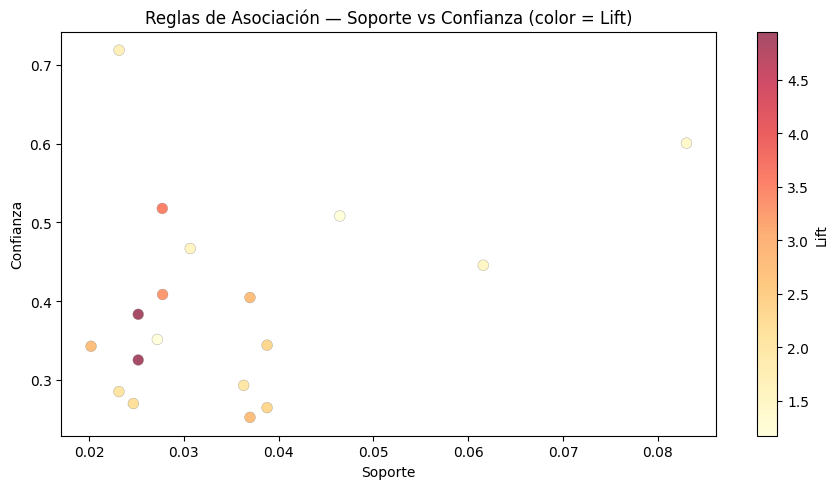

In [ ]:
# ── 6. Scatter Soporte vs Confianza ─────────────────────────────────────────

rules_fpgrowth = rules_fpgrowth[rules_fpgrowth['lift'] > 1]

fig, ax = plt.subplots(figsize=(9, 5))

sc = ax.scatter(
    rules_fpgrowth['support'],
    rules_fpgrowth['confidence'],
    c=rules_fpgrowth['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='gray',
    linewidths=0.3,
    s=60
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Soporte')
ax.set_ylabel('Confianza')
ax.set_title('Reglas de Asociación — Soporte vs Confianza (color = Lift)')
plt.tight_layout()
plt.show()


#### Top 10 Reglas por Lift

El **lift** mide cuánto más frecuente es la co-ocurrencia respecto al azar. Lift > 1 indica asociación positiva real.

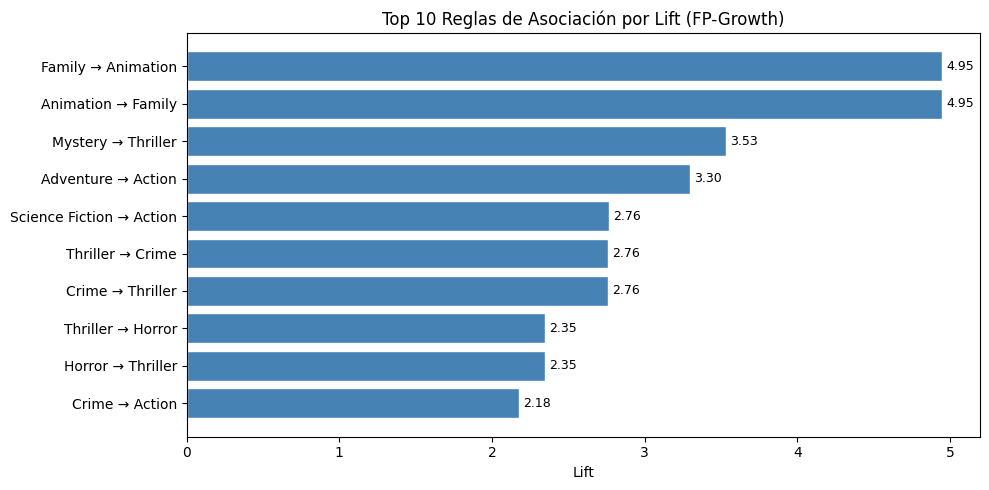


Detalle de las 10 reglas con mayor lift:


,regla,support,confidence,lift
0,Family → Animation,0.025186,0.383264,4.949163
1,Animation → Family,0.025186,0.325235,4.949163
2,Mystery → Thriller,0.027726,0.517726,3.532955
3,Adventure → Action,0.027760,0.408456,3.295863
4,Science Fiction → Action,0.020209,0.342662,2.764970
5,Thriller → Crime,0.036980,0.252349,2.760494
6,Crime → Thriller,0.036980,0.404528,2.760494
7,Thriller → Horror,0.038784,0.264663,2.347654
8,Horror → Thriller,0.038784,0.344030,2.347654
9,Crime → Action,0.024673,0.269904,2.177873


In [ ]:
# ── 7. Top 10 reglas por Lift ────────────────────────────────────────────────
top10 = rules_fpgrowth.nlargest(10, 'lift').copy()
top10['regla'] = (
    top10['antecedents'].apply(lambda x: ', '.join(sorted(x))) +
    ' → ' +
    top10['consequents'].apply(lambda x: ', '.join(sorted(x)))
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['regla'], top10['lift'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('Lift')
ax.set_title('Top 10 Reglas de Asociación por Lift (FP-Growth)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n10 reglas con mayor lift:")
display(top10[['regla','support','confidence','lift']].reset_index(drop=True))


#### **8.1.5 Interpretación**

Las 25 reglas generadas (todas con lift > 1) muestran asociaciones entre géneros.
Las más fuertes son:

- Family ↔ Animation (lift ≈ 4.95): la asociación más fuerte del catálogo. Es
  bidireccional y con alta confianza (38%), lo que indica que Animation y Family
  son géneros inseparables en TMDB.

- Mystery → Thriller (lift 3.53, confianza 52%): más de la mitad de las películas
  de misterio también son de thriller, una relación esperable pero
  cuantitativamente fuerte.

- Adventure → Action (lift 3.30) y Science Fiction → Action (lift 2.76): los
  géneros de acción rara vez aparecen solos, casi
  siempre están acompañados de aventura o ciencia ficción.

- Crime ↔ Thriller ↔ Horror: forman un clúster de géneros oscuros fuertemente
 conectados, con lifts entre 2.35 y 2.76.

Apriori vs FP-Growth: ambos algoritmos generaron las mismas 25 reglas
con los mismos valores de soporte, confianza y lift. En este dataset, Apriori resultó
más rápido (0.21s vs 18.8s), lo cual es coherente con la literatura: FP-Growth
supera a Apriori cuando el número de ítems frecuentes es grande o el soporte mínimo
es muy bajo. Con solo 39 ítems frecuentes y un umbral de 2%, el overhead de
construir el FP-Tree supera su ventaja algorítmica.

### **8.2. Procedimiento para Agrupación**

--------------

PONER AQUÍ TODO LO DE AGRUPACIOOOOON

--------------